**Model Building**

**Import Libraries**

In [1]:
import ants
import antspynet
import torch
import torchio as tio

c:\Users\hp\OneDrive\Documents\fyp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Function**

In [2]:
# Input: a nii.gz file path
# Output: a tensor of the image, and a tensor of the mask

def preprocess_3d_mri(mri_path, modality=1):
    # Load the image
    image = ants.image_read(mri_path)

    # 1. Reorient the image to RAS
    reoriented_image = ants.reorient_image2(image, orientation='RAS')

    # 2. Extract brain
    if modality == 1:
        brain_mask = antspynet.brain_extraction(reoriented_image, modality="t1", verbose=False)
    else:
        brain_mask = antspynet.brain_extraction(reoriented_image, modality="t2", verbose=False)

    extracted_image = reoriented_image * brain_mask

    # 3. Normalise intensity using 99th percentile not including zeros
    torchio_subject = tio.Subject(
        image = tio.ScalarImage(tensor=torch.from_numpy(extracted_image.numpy()).unsqueeze(0)),
        mask = tio.ScalarImage(tensor=torch.from_numpy(brain_mask.numpy()).unsqueeze(0))
    )
    normalised_subject = tio.RescaleIntensity(percentiles=(0,99), masking_method=lambda x:x>0)(torchio_subject)

    # 4. Resample to 1x1x1
    resampled_subject = tio.Resample((1,1,1))(normalised_subject)

    # 5. Crop to 225x225x225
    cropped_subject = tio.CropOrPad((225,225,225))(resampled_subject)

    # 6. Resized to 128
    resized_subject = tio.Resize(target_shape=(128,128,128), image_interpolation='nearest')(cropped_subject)

    return resized_subject.image.data, resized_subject.mask.data

In [3]:
# Input: a tensor of the image, a tensor of the mask
# Output: a tensor of the image with noise

def generate_noise(image, mask):
    # Generate Gaussian noise using the image's mean and standard deviation
    noise = torch.randn_like(image) * image.std() + image.mean()

    # Apply noise to the image
    noisy_image = image.clone()
    noisy_image = image + noise * mask

    return noisy_image

**Model Building**

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [5]:
# Swish activation function
class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

In [6]:
# FiLM layer
class FiLM(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.gamma = nn.Linear(2, channels)  # 2 for one-hot T1/T2
        self.beta = nn.Linear(2, channels)

    def forward(self, x, modality):
        gamma = self.gamma(modality)
        beta = self.beta(modality)
        
        return gamma.view(-1, x.size(1), 1, 1, 1) * x + beta.view(-1, x.size(1), 1, 1, 1) # Reshape for 3D

In [7]:
# Weight-Standardized 3D Convolution
class WSConv3d(nn.Conv3d):
    def forward(self, x):
        weight = self.weight

        # Compute mean and std per output channel
        mean = weight.mean(dim=(1,2,3,4), keepdim=True)
        std = weight.std(dim=(1,2,3,4), keepdim=True) + 1e-5  # Add epsilon for numerical stability

        # Normalize weights
        weight = (weight - mean) / std

        # Perform convolution with standardized weights
        return F.conv3d(x, weight, self.bias, self.stride, self.padding, self.dilation, self.groups)

In [8]:
# Convolutional block
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, num_groups=8):
        super().__init__()
        self.conv1 = WSConv3d(in_channels, out_channels, kernel_size=3, padding=1)
        self.norm1 = nn.GroupNorm(num_groups, out_channels)
        self.film1 = FiLM(out_channels) 
        self.swish1 = Swish()

        self.conv2 = WSConv3d(out_channels, out_channels, kernel_size=3, padding=1)
        self.norm2 = nn.GroupNorm(num_groups, out_channels)
        self.film2 = FiLM(out_channels) 
        self.swish2 = Swish()

    def forward(self, x, modality):
        x = self.conv1(x)
        x = self.norm1(x)
        x = self.film1(x, modality)
        x = self.swish1(x)

        x = self.conv2(x)
        x = self.norm2(x)
        x = self.film2(x, modality)
        x = self.swish2(x)
        
        return x

In [9]:
# Downsampling Block 
class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = ConvBlock(in_channels, out_channels)
        self.pool = nn.MaxPool3d(2)

    def forward(self, x, modality):
        x = self.conv(x, modality)
        p = self.pool(x)
        return x, p  

In [10]:
# Upsampling Block
class UpBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.upconv = nn.ConvTranspose3d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = ConvBlock(out_channels * 2, out_channels)  # Concatenation doubles channels

    def forward(self, x, skip, modality):
        x = self.upconv(x)
        x = torch.cat([x, skip], dim=1)  # Concatenate with skip connection
        x = self.conv(x, modality)
        return x

In [11]:
# Full 3D U-Net
class UNet3D(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base_filters=32):
        super().__init__()
        self.down1 = DownBlock(in_channels, base_filters)
        self.down2 = DownBlock(base_filters, base_filters * 2)
        self.down3 = DownBlock(base_filters * 2, base_filters * 4)

        self.bottleneck = ConvBlock(base_filters * 4, base_filters * 8)

        self.up3 = UpBlock(base_filters * 8, base_filters * 4)
        self.up2 = UpBlock(base_filters * 4, base_filters * 2)
        self.up1 = UpBlock(base_filters * 2, base_filters)

        self.final_conv = nn.Conv3d(base_filters, out_channels, kernel_size=1)  # 1x1x1 to get output

    def forward(self, x, modality):
        s1, p1 = self.down1(x, modality)
        s2, p2 = self.down2(p1, modality)
        s3, p3 = self.down3(p2, modality)

        b = self.bottleneck(p3, modality)

        u3 = self.up3(b, s3, modality)
        u2 = self.up2(u3, s2, modality)
        u1 = self.up1(u2, s1, modality)

        out = self.final_conv(u1)
        return out

In [12]:
import os
from torch.utils.data import Dataset, DataLoader

class MRIDataset(Dataset):
    def __init__(self, t1_dir, t2_dir):
        self.t1_files = [os.path.join(t1_dir, f) for f in os.listdir(t1_dir) if f.endswith('.nii.gz')]
        self.t2_files = [os.path.join(t2_dir, f) for f in os.listdir(t2_dir) if f.endswith('.nii.gz')]
        self.files = self.t1_files + self.t2_files  # Combine T1 and T2 files

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_path = self.files[idx]
        modality = torch.tensor([1, 0], dtype=torch.float32) if file_path in self.t1_files else torch.tensor([0, 1], dtype=torch.float32)

        # Load and preprocess
        image, mask = preprocess_3d_mri(file_path, modality=1 if file_path in self.t1_files else 2)
        
        # Generate noisy image
        noisy_image = generate_noise(image, mask)

        return noisy_image, image, modality  # Noisy input, Ground truth, Modality info

**Train Model**

In [13]:
from torch.utils.data import random_split, DataLoader

# Define dataset
t1_file_path = r"C:\Users\hp\Downloads\IXI-T1"
t2_file_path = r"C:\Users\hp\Downloads\IXI-T2"
dataset = MRIDataset(t1_file_path, t2_file_path)

dataset.files = dataset.files[:15]

# Split sizes
total_size = len(dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size  # Ensure no data is lost

# Perform the split
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

# Create DataLoaders
batch_size = 2  
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet3D().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

In [15]:
num_epochs = 3

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for noisy_img, clean_img, modality in train_loader:
        noisy_img, clean_img, modality = noisy_img.to(device), clean_img.to(device), modality.to(device)

        optimizer.zero_grad()
        output = model(noisy_img, modality)
        loss = criterion(output, clean_img)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)
    
    # Run Validation
    model.eval()  # Set model to evaluation mode
    val_loss = 0.0
    with torch.no_grad():  # No gradients needed for validation
        for noisy_img, clean_img, modality in val_loader:
            noisy_img, clean_img, modality = noisy_img.to(device), clean_img.to(device), modality.to(device)
            output = model(noisy_img, modality)
            loss = criterion(output, clean_img)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.6f} - Val Loss: {avg_val_loss:.6f}")

c:\Users\hp\OneDrive\Documents\fyp\.venv\Lib\site-packages\torchio\data\image.py:248: UserWarning: Using TorchIO images without a torchio.SubjectsLoader in PyTorch >= 2.3 might have unexpected consequences, e.g., the collated batches will be instances of torchio.Subject with 5D images. Replace your PyTorch DataLoader with a torchio.SubjectsLoader so that the collated batch becomes a dictionary, as expected. See https://github.com/fepegar/torchio/issues/1179 for more context about this issue.
  warnings.warn(message, stacklevel=1)


Epoch [1/3] - Train Loss: 0.032017 - Val Loss: 0.017964
Epoch [2/3] - Train Loss: 0.014989 - Val Loss: 0.011428
Epoch [3/3] - Train Loss: 0.011023 - Val Loss: 0.010089


In [ ]:
torch.save(model.state_dict(), "unet_mri_denoising.pth")

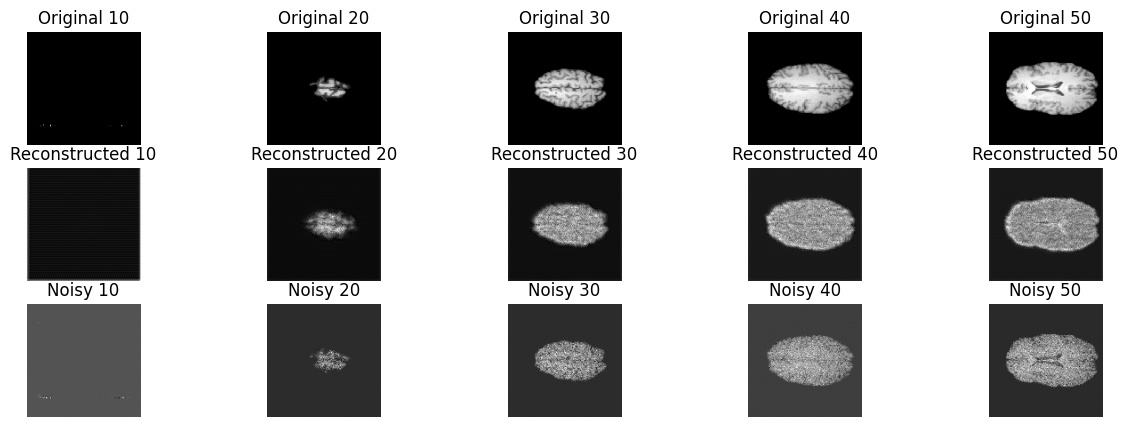

In [33]:
model.eval()  # Set model to evaluation mode

# Get the first batch from the DataLoader
noisy_image, original_image, modality = next(iter(test_loader))

# Move to device if using GPU
noisy_image, modality = noisy_image.to(device), modality.to(device)

# Run inference
with torch.no_grad():
    reconstructed_image = model(noisy_image, modality)

# Visualize the results
import matplotlib.pyplot as plt

def plot_first_image(original, reconstructed, noisy_image, num_slices=5):
    original = original_image[0, 0].cpu().numpy()
    reconstructed = reconstructed_image[0, 0].cpu().numpy()
    noisy_image = noisy_image[0, 0].cpu().numpy()

    slice_indices = [10, 20, 30, 40, 50]  # Select some slices

    fig, axes = plt.subplots(3, num_slices, figsize=(15, 5))
    for i, slice_idx in enumerate(slice_indices):
        axes[0, i].imshow(original[:, :, slice_idx], cmap="gray")
        axes[0, i].set_title(f"Original {slice_idx}")
        axes[0, i].axis("off")

        axes[1, i].imshow(reconstructed[:, :, slice_idx], cmap="gray")
        axes[1, i].set_title(f"Reconstructed {slice_idx}")
        axes[1, i].axis("off")

        axes[2, i].imshow(noisy_image[:, :, slice_idx], cmap="gray")
        axes[2, i].set_title(f"Noisy {slice_idx}")
        axes[2, i].axis("off")

    plt.show()

plot_first_image(original_image, reconstructed_image, noisy_image)


**Save Preprocessed Data**

In [41]:
import torch
import os

# Define paths
t1_input = r"C:\Users\hp\Downloads\IXI-T1"
t2_input = r"C:\Users\hp\Downloads\IXI-T2"

t1_output = r"C:\Users\hp\Downloads\IXI-T1-Preprocessed"
t2_output = r"C:\Users\hp\Downloads\IXI-T2-Preprocessed"

# Create output directories if they don't exist
os.makedirs(t1_output, exist_ok=True)
os.makedirs(t2_output, exist_ok=True)

# Get all MRI files with full paths
t1_files = [os.path.join(t1_input, f) for f in os.listdir(t1_input) if f.endswith('.nii.gz')]
t2_files = [os.path.join(t2_input, f) for f in os.listdir(t2_input) if f.endswith('.nii.gz')]

# Process files
for i, file_path in enumerate(t1_files + t2_files):
    # Determine modality based on the folder
    if file_path in t1_files:
        modality = torch.tensor([1, 0], dtype=torch.float32)  # T1-weighted
        save_dir = t1_output
    else:
        modality = torch.tensor([0, 1], dtype=torch.float32)  # T2-weighted
        save_dir = t2_output

    # Process image
    image, mask = preprocess_3d_mri(file_path)  # Load and preprocess
    noisy_image = generate_noise(image, mask)  # Generate noisy version

    # Save as a dictionary
    save_path = os.path.join(save_dir, f"sample_{i}.pt")
    torch.save({"noisy_image": noisy_image, "original_image": image, "modality": modality}, save_path)

print("Preprocessing complete. Data saved!")


RuntimeError: [enforce fail at inline_container.cc:626] . unexpected pos 8389376 vs 8389264

In [37]:
import torch
import os

# Path to preprocessed data
save_dir = r"C:\Users\hp\Downloads\IXI-T1-Preprocessed"

# List all saved .pt files
files = [f for f in os.listdir(save_dir) if f.endswith('.pt')]

# Load the first sample
sample_path = os.path.join(save_dir, files[0])  # First saved sample
data = torch.load(sample_path)  # Load the dictionary

# Extract contents
noisy_image = data["noisy_image"]
original_image = data["original_image"]
modality = data["modality"]

# Print shapes
print("Noisy Image Shape:", noisy_image.shape)
print("Original Image Shape:", original_image.shape)
print("Modality:", modality)


Noisy Image Shape: torch.Size([1, 128, 128, 128])
Original Image Shape: torch.Size([1, 128, 128, 128])
Modality: tensor([0., 1.])


In [15]:
import numpy as np

def save_to_npz(file_path, noisy_image, ground_truth):
    # Convert tensors to NumPy arrays
    np.savez_compressed(file_path, 
                        noisy_image=noisy_image.numpy(), 
                        ground_truth=ground_truth.numpy())


In [16]:
path = r"C:\Users\hp\Downloads\IXI-T1\IXI425-IOP-0988-T1.nii.gz"

image, mask = preprocess_3d_mri(path, modality=1)
noisy_image = generate_noise(image, mask)

type(noisy_image)

torch.Tensor

In [18]:
save_to_npz(r"C:\Users\hp\Downloads\mri_data.npz", noisy_image, image)

In [19]:
def load_from_npz(file_path):
    data = np.load(file_path)  # Load .npz file
    noisy_image = torch.tensor(data["noisy_image"])  # Convert back to tensor
    ground_truth = torch.tensor(data["ground_truth"])
    return noisy_image, ground_truth


In [20]:
# Example usage:
noisy_image_loaded, ground_truth_loaded = load_from_npz(r"C:\Users\hp\Downloads\mri_data.npz")

print(noisy_image_loaded.shape, ground_truth_loaded.shape)

torch.Size([1, 128, 128, 128]) torch.Size([1, 128, 128, 128])
